In [ ]:
from numpy import *

class LinearRegression:
    def __init__(self, x, y):
      self.x = x
      self.y = y
      self.__correlation_coefficient =  self.__correlacao()
      self.__inclination_coefficient = self.__inclinacao()
      self.__intercept_coefficient = self.__interceptacao()

    def __correlacao(self):
      covariacao = cov(self.x, self.y, bias=True)[0][1]
      #bias = -1 no cálculo faz normalização por N
      #por padrão o calculo da covariacao vem dentro de uma matriz
      #como queremos o valor de x e y, pegaremos ela de dentro da matriz dessa forma
      variancia_x = var(self.x)
      variancia_y = var(self.y)
      return covariacao / sqrt(variancia_x * variancia_y)

    def __inclinacao(self):
      stdx = std(self.x)
      stdy = std(self.y)
      return self.__correlation_coefficient * (stdy / stdx)

    def __interceptacao(self):
      mediax = mean(self.x)
      mediay = mean(self.y)
      return mediay - mediax * self.__inclination_coefficient

    def previsao(self,valor):
      return self.__intercept_coefficient + (self.__inclination_coefficient * valor)

In [ ]:
x = array([1,2,3,4,5])
y = array([2,4,6,8,10])
lr = LinearRegression(x,y)
previsao = lr.previsao(7)
print(previsao)

14.0


      Area_m2         Preco
0  118.653425  6.758785e+05
1  239.650004  1.269280e+06
2  193.718728  1.051346e+06
3  165.718282  8.489643e+05
4   72.763914  4.372294e+05

Equação da Regressão:
Preço = 4934.32 * Área + 89080.16
R² = 0.9923

Previsões:
Área: 60 m² -> Preço Previsto: R$ 385,139.25
Área: 100 m² -> Preço Previsto: R$ 582,511.97
Área: 150 m² -> Preço Previsto: R$ 829,227.88
Área: 200 m² -> Preço Previsto: R$ 1,075,943.78


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


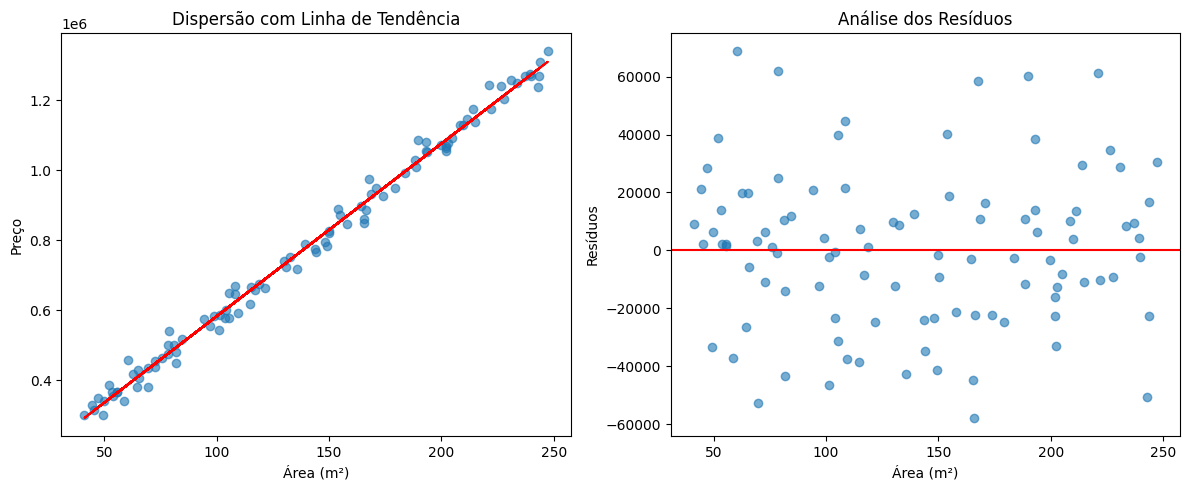

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1️⃣ Gerar dados
np.random.seed(42)

n = 100
area = np.random.uniform(40, 250, n)  # áreas entre 40m² e 250m²
ruido = np.random.normal(0, 30000, n)  # ruído com desvio padrão de 30 mil

preco = 5000 * area + 80000 + ruido

df = pd.DataFrame({
    "Area_m2": area,
    "Preco": preco
})

print(df.head())

# 2️⃣ Ajustar regressão linear
X = df[["Area_m2"]]
y = df["Preco"]

modelo = LinearRegression()
modelo.fit(X, y)

coef = modelo.coef_[0]
intercept = modelo.intercept_

# 3️⃣ Avaliar modelo
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

print("\nEquação da Regressão:")
print(f"Preço = {coef:.2f} * Área + {intercept:.2f}")
print(f"R² = {r2:.4f}")

# 4️⃣ Prever preços para áreas específicas
areas_teste = np.array([[60], [100], [150], [200]])
previsoes = modelo.predict(areas_teste)

print("\nPrevisões:")
for a, p in zip(areas_teste.flatten(), previsoes):
    print(f"Área: {a} m² -> Preço Previsto: R$ {p:,.2f}")

# 5️⃣ Analisar resíduos
residuos = y - y_pred

plt.figure(figsize=(12,5))

# Gráfico de dispersão com linha de tendência
plt.subplot(1,2,1)
plt.scatter(area, preco, alpha=0.6)
plt.plot(area, y_pred, color='red')
plt.xlabel("Área (m²)")
plt.ylabel("Preço")
plt.title("Dispersão com Linha de Tendência")

# Gráfico dos resíduos
plt.subplot(1,2,2)
plt.scatter(area, residuos, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Área (m²)")
plt.ylabel("Resíduos")
plt.title("Análise dos Resíduos")

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import scipy.stats as stats
import seaborn as sns

base = pd.read_csv('mt_cars.csv')
base.shape #veremos o arquivo em número de linhas e colunas!
base.head()
base = base.drop(['Unnamed: 0'], axis = 1) #Removeremos a primeira coluna não a linha

<Axes: >

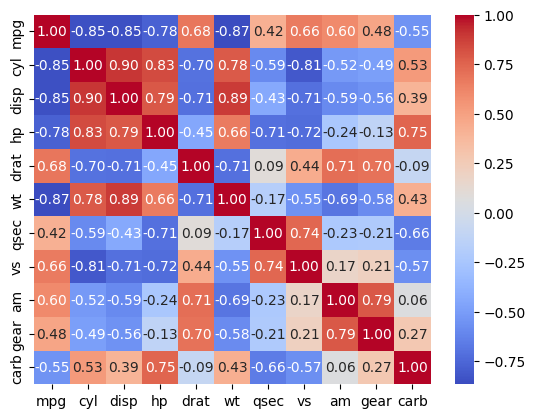

In [16]:
corr = base.corr() #gera um objeto que tem uma matriz com essas correlações
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f') #aqui é gerado um gráfico com essas correlações

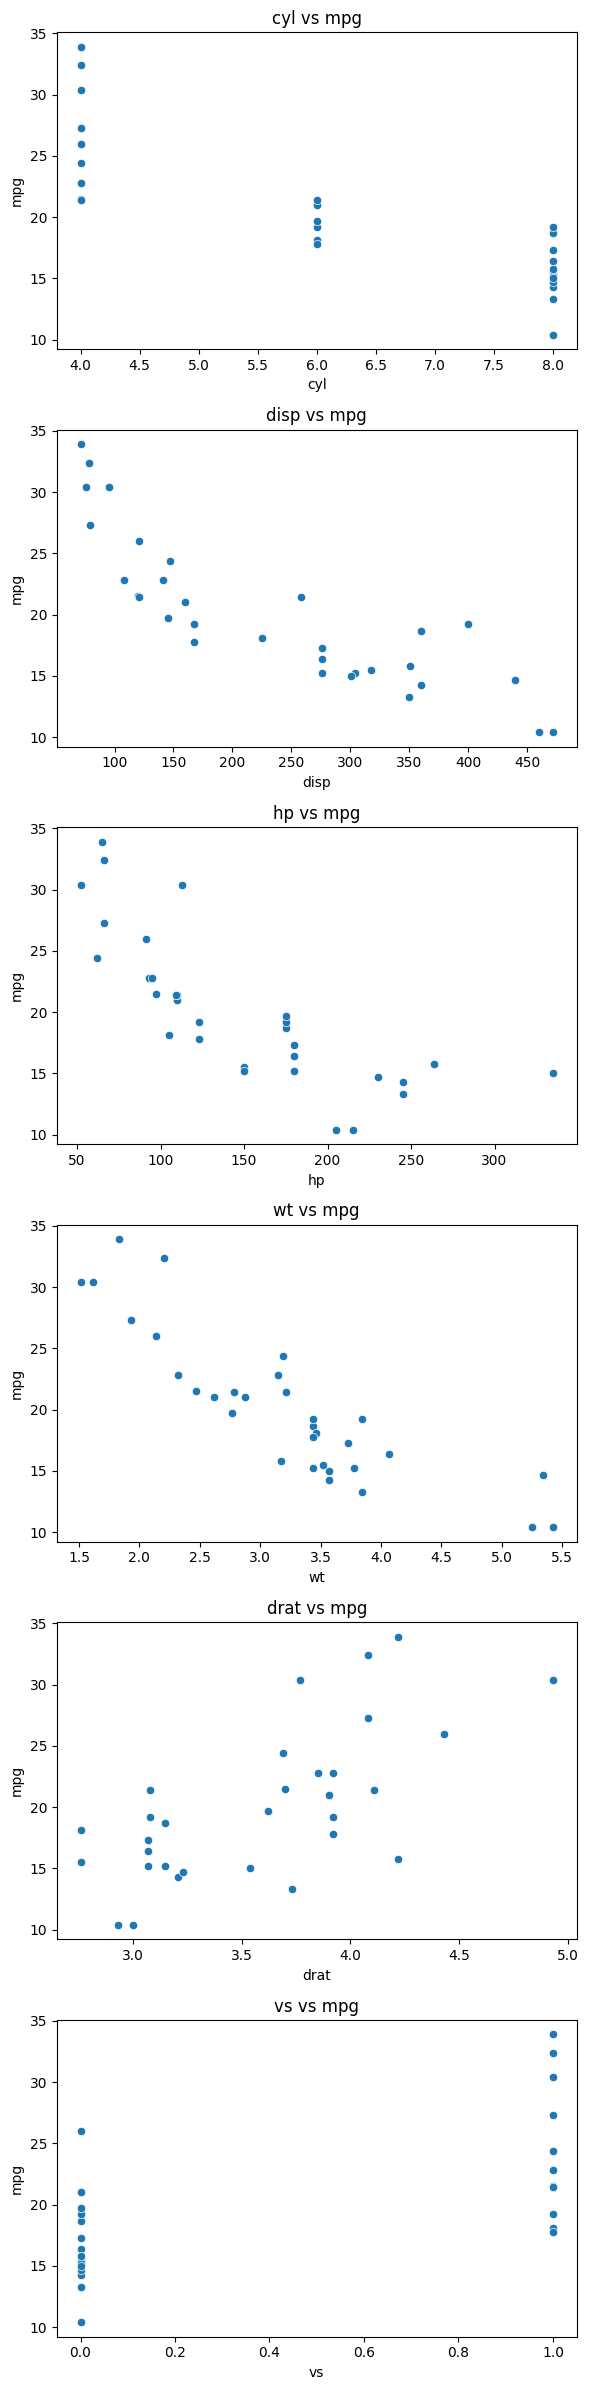

In [17]:
column_pairs = [('cyl', 'mpg'),('disp', 'mpg'),('hp', 'mpg'),('wt', 'mpg'),('drat', 'mpg'),('vs', 'mpg')]
n_plots = len(column_pairs)
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(6,4 * n_plots))

for i, pair in enumerate(column_pairs):
  x_col, y_col = pair
  sns.scatterplot(x=x_col, y=y_col,data=base, ax=axes[i])
  axes[i].set_title(f'{x_col} vs {y_col}')

plt.tight_layout() #aqui a plotagem fica ajustada!
plt.show()


In [20]:
# usando formulas, colocar as variáveis dependentes na esquerda, um "~" e as variaveis independentes na esquerda
#muitas coisas serao na base do teste e erro
modelo = sm.ols(formula='mpg ~ wt + disp + hp', data=base)
modelo = modelo.fit()
modelo.summary()
#aic = 156.6 bic = 162.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     44.57
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           8.65e-11
Time:                        18:39:34   Log-Likelihood:                -74.321
No. Observations:                  32   AIC:                             156.6
Df Residuals:                      28   BIC:                             162.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.1055      2.111     17.579      0.000      32.782      41.429
wt            -3.8009      1.066     -3.565      0.001      -5.985      -1.617
disp          -0.0009      0.010     -0.091      0.929      -0.022       0.020
hp            -0.0312      0.011     -2.724      0.011      -0.055      -0.008
==============================================================================
Omnibus:                        5.269   Durbin-Watson:                   1.367
Prob(Omnibus):                  0.072   Jarque-Bera (JB):                4.038
Skew:                           0.856   Prob(JB):                        0.133
Kurtosis:                       3.310   Cond. No.                     1.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [21]:
modelo = sm.ols(formula='mpg ~ drat + vs', data=base)
modelo = modelo.fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     24.53
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.82e-07
Time:                        18:39:37   Log-Likelihood:                -86.536
No. Observations:                  32   AIC:                             179.1
Df Residuals:                      29   BIC:                             183.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8253      4.903     -0.372      0.712     -11.853       8.202
drat           5.4365      1.421      3.826      0.001       2.530       8.343
vs             5.4013      1.507      3.583      0.001       2.318       8.484
==============================================================================
Omnibus:                        0.243   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.886   Jarque-Bera (JB):                0.440
Skew:                           0.059   Prob(JB):                        0.803
Kurtosis:                       2.438   Cond. No.                         29.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
modelo = sm.ols(formula='mpg ~ cyl + vs', data=base)
modelo = modelo.fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     38.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.23e-09
Time:                        18:39:39   Log-Likelihood:                -81.529
No. Observations:                  32   AIC:                             169.1
Df Residuals:                      29   BIC:                             173.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.6250      4.225      9.380      0.000      30.985      48.265
cyl           -3.0907      0.558     -5.538      0.000      -4.232      -1.949
vs            -0.9391      1.978     -0.475      0.638      -4.984       3.105
==============================================================================
Omnibus:                        1.325   Durbin-Watson:                   1.688
Prob(Omnibus):                  0.516   Jarque-Bera (JB):                1.070
Skew:                           0.434   Prob(JB):                        0.586
Kurtosis:                       2.781   Cond. No.                         52.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

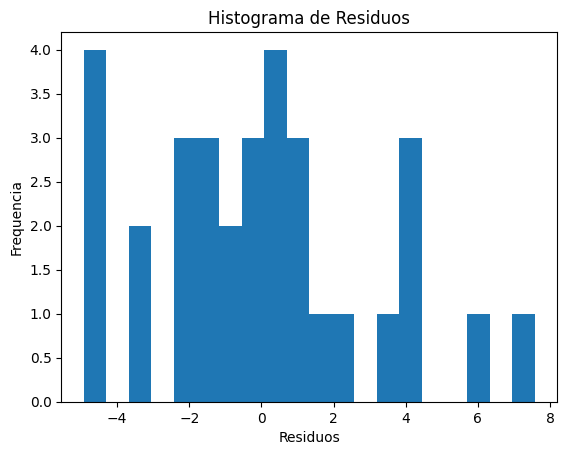

In [23]:
# Analisando os Residuais do Modelo Anterior
residuos = modelo.resid
plt.hist(residuos, bins=20)
plt.xlabel("Residuos")
plt.ylabel("Frequencia")
plt.title("Histograma de Residuos")
plt.show()

In [25]:
# Teste de Shapiro-Wilk
# h0 - dados estão normalmente distribuidos
# p <= 0.05 rejeito a hipótese nula, (não estão normalmente distribuidos)
# p > 0.05 não é possivel rejeitar a h0
stat, pval = stats.shapiro(residuos)
print(f'Shapiro-Wilk statística: {stat:.3f}, p-value: {pval:.3f}')

Shapiro-Wilk statística: 0.964, p-value: 0.358


In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(42)

n = 200

Invest_Ads = np.random.uniform(1000, 10000, n)
Invest_Instagram = np.random.uniform(500, 5000, n)
Invest_Email = np.random.uniform(100, 2000, n)

# Modelo verdadeiro
Vendas = (
    500 +
    8 * Invest_Ads +
    4 * Invest_Instagram +
    1.5 * Invest_Email +
    np.random.normal(0, 10000, n)
)

df = pd.DataFrame({
    "Invest_Ads": Invest_Ads,
    "Invest_Instagram": Invest_Instagram,
    "Invest_Email": Invest_Email,
    "Vendas": Vendas
})

X = df[["Invest_Ads", "Invest_Instagram", "Invest_Email"]]
X = sm.add_constant(X)
y = df["Vendas"]

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     292.8
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           3.88e-72
Time:                        18:56:52   Log-Likelihood:                -2127.6
No. Observations:                 200   AIC:                             4263.
Df Residuals:                     196   BIC:                             4276.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              121.1538   2775.963  

In [41]:
import pandas as pd #vamos trazer dados de seguro!
from sklearn.model_selection import train_test_split #dividir os dados entre TREINO  e TESTE!
from sklearn.naive_bayes import GaussianNB #Dados Contínuos!
from sklearn.preprocessing import LabelEncoder #Transformação de Dados Categóricos em Informações Numéricas (dados conínos...)
from sklearn.metrics import accuracy_score #metricas estudadas anteriormente
from sklearn.metrics import precision_score #metricas estudadas anteriormente
from sklearn.metrics import recall_score #metricas estudadas anteriormente
from sklearn.metrics import f1_score #metricas estudadas anteriormente
from sklearn.metrics import classification_report #metricas estudadas anteriormente
from yellowbrick.classifier import ConfusionMatrix #para criar nossa matriz de confusão visual (gráfica)
base = pd.read_csv('/content/insurance.csv')
base = base.drop(columns=['Unnamed: 0'])
base

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,NaN,Football,NaN,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,NaN,Football,NaN,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,NaN,EggShell,NaN,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,Adult,Prole,Adventurous,Older,Mild,Football,Mild,Economy,Poor,...,City,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Many
19996,False,Adult,Middle,Normal,Older,NaN,Tank,NaN,FamilySedan,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Good,False,Thousand,Zero
19997,False,Senior,UpperMiddle,Normal,Current,NaN,Football,NaN,Luxury,Excellent,...,Secure,True,TenThou,Thousand,False,Thousand,Excellent,True,Thousand,Zero
19998,False,Adult,Middle,Normal,Older,NaN,Football,NaN,FamilySedan,Excellent,...,Suburb,False,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero


In [58]:
#uma tradição é usar a variável dependente como "y" as independetes como "X"
y = base.iloc[:,7].values #quero todas as linhas, no entanto somente da coluna 7! -> índice 7 tem a coluna acidente
X = base.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26]].values #tenho todas as colunas menos a 7

In [59]:
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [60]:
y

array(['Mild', nan, nan, ..., nan, nan, nan], dtype=object)

In [62]:
labelencoder = LabelEncoder()

#agora vamos percorrer as colunas para transformar elas através do label encoder
#apesar de nosso database só ter dados categóricos, será criado um código genérico
#vamos criar um laço que vai percorrer o total de colunas d objeto:
for i in range(X.shape[1]):
  if X[:,i].dtype == 'object': #esse código só transforma objetos categóricos
    X[:,i] = labelencoder.fit_transform(X[:,i]) #transforma os dados da mesma coluna em dados numéricos
y = labelencoder.fit_transform(y)

In [61]:
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [63]:
y

array([0, 3, 3, ..., 3, 3, 3])

In [75]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X,y,test_size=0.3, random_state=1)

In [77]:
modelo = GaussianNB()
modelo.fit(X_treinamento,y_treinamento)

previsoes = modelo.predict(X_teste)
previsoes

accuracy = accuracy_score(y_teste, previsoes)

In [79]:
precision = precision_score(y_teste, previsoes, average='weighted')

In [81]:
recall = recall_score(y_teste, previsoes, average='weighted')
f1 = f1_score(y_teste, previsoes, average='weighted')
print(f'Acuracia: {accuracy}, Precisão: {precision}, Recall {recall}, F1: {f1}')

Acuracia: 0.8361666666666666, Precisão: 0.8984416515911416, Recall 0.8361666666666666, F1: 0.8090758902175055


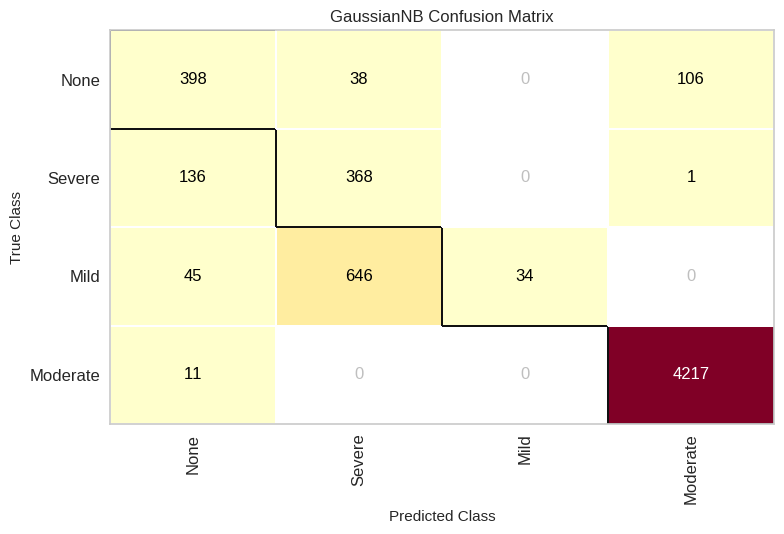

<Axes: title={'center': 'GaussianNB Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [82]:
#nesse caso a matriz de confusão será 4 x 4 porque temos 4 classes possíveis!
confusao = ConfusionMatrix(modelo, classes=['None','Severe','Mild','Moderate'])
confusao.fit(X_treinamento,y_treinamento)
confusao.score(X_teste,y_teste)
confusao.poof()